# StealthVision — Pipeline de Detección de Riesgo Vial
### Educación vial para niños y jóvenes menores de 18 años

---

Este cuadernillo implementa el pipeline completo:

```
Imagen / Frame de Unreal Engine
         ↓
  RT-DETR ONNX (detección multi-clase)
  → person, bicycle, car, motorcycle, bus, truck, traffic light, stop sign
         ↓
  TrafficRiskEngine (análisis de escenarios)
         ↓
  Resultado educativo: SAFE / WARNING / CRITICAL + lección
```

**Clases COCO que aprovechamos (sin reentrenar nada):**

| ID | Clase | Relevancia |
|---|---|---|
| 0 | person | Peatón, niño |
| 1 | bicycle | Ciclista |
| 2 | car | Auto |
| 3 | motorcycle | Moto |
| 5 | bus | Bus escolar / urbano |
| 7 | truck | Camión |
| 9 | traffic light | Semáforo |
| 11 | stop sign | Señal de pare |

## Verificación del entorno

In [1]:
import sys, os
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, Image as IPImage

# --- ONNX Runtime ---
try:
    import onnxruntime as ort
    providers = ort.get_available_providers()
    print("ONNX Runtime:", ort.__version__)
    print("Providers disponibles:", providers)
    gpu_ok = "CUDAExecutionProvider" in providers
    print("GPU (CUDA):", "SI" if gpu_ok else "NO — se usara CPU")
except ImportError:
    print("ERROR: instala onnxruntime-gpu con:  pip install onnxruntime-gpu")

# --- PyTorch (opcional, solo para info) ---
try:
    import torch
    print("PyTorch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
except ImportError:
    print("PyTorch no instalado (no requerido para inferencia ONNX)")

# --- Modelo ---
MODEL_PATH = "rtdetr-l.onnx"
exists = os.path.exists(MODEL_PATH)
size_mb = os.path.getsize(MODEL_PATH) / 1e6 if exists else 0
print(f"\nModelo {MODEL_PATH}: {'OK (' + str(round(size_mb)) + ' MB)' if exists else 'NO ENCONTRADO'}")

ONNX Runtime: 1.24.3
Providers disponibles: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
GPU (CUDA): SI
PyTorch: 2.10.0+cu130 | CUDA: True

Modelo rtdetr-l.onnx: OK (132 MB)


## Clase Detector (multi-clase)

In [2]:
import onnxruntime as ort
import numpy as np
import cv2
from typing import List, Dict, Any, Set, Optional

# Clases COCO80
COCO_CLASSES = {
    0: "person", 1: "bicycle", 2: "car", 3: "motorcycle",
    4: "airplane", 5: "bus", 6: "train", 7: "truck",
    8: "boat", 9: "traffic light", 10: "fire hydrant",
    11: "stop sign", 12: "parking meter", 43: "knife",
    67: "cell phone"
}

# Clases de tráfico que nos interesan
TRAFFIC_CLASS_IDS = {0, 1, 2, 3, 5, 7, 9, 11}


class RTDetrDetector:
    def __init__(self, model_path="rtdetr-l.onnx", conf_threshold=0.4,
                 target_class_ids=None, providers=None):
        if providers is None:
            providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]
        self.model_path = model_path
        self.conf_threshold = conf_threshold
        self.target_class_ids = set(target_class_ids) if target_class_ids else {0}
        self.session = ort.InferenceSession(model_path, providers=providers)
        self.input_name = self.session.get_inputs()[0].name
        _, _, self.in_h, self.in_w = self.session.get_inputs()[0].shape
        names = [COCO_CLASSES.get(c, str(c)) for c in sorted(self.target_class_ids)]
        print(f"Detector listo | input {self.in_w}x{self.in_h} | clases: {names}")
        print(f"Backend activo: {self.session.get_providers()[0]}")

    def preprocess(self, image):
        oh, ow = image.shape[:2]
        scale = min(self.in_w / ow, self.in_h / oh)
        nw, nh = int(ow * scale), int(oh * scale)
        canvas = np.full((self.in_h, self.in_w, 3), 114, dtype=np.uint8)
        canvas[:nh, :nw] = cv2.resize(image, (nw, nh))
        img = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        return np.expand_dims(img.transpose(2, 0, 1), 0), scale, (oh, ow)

    def postprocess(self, outputs, scale, orig_shape):
        preds = outputs[0][0]
        boxes, scores_all = preds[:, :4], preds[:, 4:]
        cids = np.argmax(scores_all, axis=1)
        scores = scores_all[np.arange(len(cids)), cids]
        oh, ow = orig_shape
        dets = []
        for i in range(len(preds)):
            s, c = float(scores[i]), int(cids[i])
            if s < self.conf_threshold or c not in self.target_class_ids:
                continue
            xc, yc, w, h = boxes[i]
            xc *= self.in_w; yc *= self.in_h; w *= self.in_w; h *= self.in_h
            x1 = max(0, min(int((xc - w/2) / scale), ow-1))
            y1 = max(0, min(int((yc - h/2) / scale), oh-1))
            x2 = max(0, min(int((xc + w/2) / scale), ow-1))
            y2 = max(0, min(int((yc + h/2) / scale), oh-1))
            dets.append({"bbox": [x1,y1,x2,y2], "confidence": round(s,4),
                          "class_id": c, "class_name": COCO_CLASSES.get(c, str(c))})
        return dets

    def detect(self, image):
        inp, scale, orig = self.preprocess(image)
        out = self.session.run(None, {self.input_name: inp})
        return self.postprocess(out, scale, orig)

print("Clase RTDetrDetector definida OK")

Clase RTDetrDetector definida OK


## Motor de Riesgo Educativo

In [3]:
CLASS_PERSON, CLASS_BICYCLE = 0, 1
CLASS_CAR, CLASS_MOTORCYCLE = 2, 3
CLASS_BUS, CLASS_TRUCK = 5, 7
VEHICLE_CLASSES = {CLASS_CAR, CLASS_MOTORCYCLE, CLASS_BUS, CLASS_TRUCK}
LARGE_VEHICLES  = {CLASS_BUS, CLASS_TRUCK}

SCENARIOS = {
    "atropello_inminente": {
        "risk_level":  "CRITICAL",
        "titulo":      "¡PELIGRO! Riesgo de atropello",
        "explicacion": "Hay una persona muy cerca o en contacto con un vehículo. Puede ocurrir un accidente grave.",
        "leccion":     "Nunca cruces entre vehículos. Usa la senda peatonal y espera que los autos se detengan completamente.",
        "consejo":     "PARA. Mira a ambos lados. Cruza solo cuando sea seguro.",
        "color":       (0, 0, 255),
    },
    "persona_cerca_vehiculo": {
        "risk_level":  "WARNING",
        "titulo":      "Precaución: Persona cerca del tráfico",
        "explicacion": "Una persona está demasiado cerca de vehículos en movimiento.",
        "leccion":     "Mantén distancia de los vehículos. Camina siempre por la vereda.",
        "consejo":     "Retrocede a la vereda. Deja pasar los autos.",
        "color":       (0, 165, 255),
    },
    "ciclista_riesgo": {
        "risk_level":  "WARNING",
        "titulo":      "Precaución: Ciclista en zona de riesgo",
        "explicacion": "Un ciclista está entre vehículos grandes. Los conductores pueden no verlo.",
        "leccion":     "Si andas en bicicleta, usa el carril exclusivo. Nunca pases junto a camiones o buses.",
        "consejo":     "Usa la ciclovía. Sé visible con colores brillantes.",
        "color":       (0, 165, 255),
    },
    "trafico_denso": {
        "risk_level":  "WARNING",
        "titulo":      "Mucho tráfico: espera antes de cruzar",
        "explicacion": "Hay varios vehículos y peatones en la misma zona. Cruzar en este momento es peligroso.",
        "leccion":     "Con mucho tráfico, espera que la calle esté despejada o usa el semáforo en verde.",
        "consejo":     "Espera. Nunca cruces corriendo.",
        "color":       (0, 165, 255),
    },
    "peaton_calzada": {
        "risk_level":  "WARNING",
        "titulo":      "Peatón en la calzada",
        "explicacion": "Hay personas en la zona de tráfico vehicular.",
        "leccion":     "La calzada es solo para vehículos. Siempre camina por la vereda.",
        "consejo":     "Sube a la vereda inmediatamente.",
        "color":       (0, 165, 255),
    },
    # --- Escenarios de iluminación ---
    "zona_oscura": {
        "risk_level":  "WARNING",
        "titulo":      "Precaución: Zona con poca iluminación",
        "explicacion": "Esta zona está oscura o tiene muy poca luz. Es difícil ver y ser visto por los conductores.",
        "leccion":     "Evita caminar solo por callejones o zonas oscuras. Usa ropa reflectante y lleva una linterna.",
        "consejo":     "Zona oscura: usa ropa reflectante y mantente alerta.",
        "color":       (0, 100, 200),
    },
    "zona_oscura_con_trafico": {
        "risk_level":  "CRITICAL",
        "titulo":      "¡PELIGRO! Zona oscura con tráfico",
        "explicacion": "Hay poca iluminación Y vehículos en movimiento. Los conductores pueden no ver a los peatones.",
        "leccion":     "En zonas oscuras con tráfico el riesgo es muy alto. Nunca cruces sin asegurarte de que te hayan visto.",
        "consejo":     "PELIGRO: Espera luz o señal antes de cruzar.",
        "color":       (0, 0, 200),
    },
    "zona_segura": {
        "risk_level":  "SAFE",
        "titulo":      "Zona segura",
        "explicacion": "No se detectaron situaciones de riesgo inmediato.",
        "leccion":     "¡Bien! Pero siempre mira a ambos lados antes de cruzar, aunque el camino parezca libre.",
        "consejo":     "Sigue las normas de tránsito siempre.",
        "color":       (0, 200, 0),
    },
}


def analyze_lighting(image):
    """
    Analiza el nivel de iluminación de la imagen BGR.
    Devuelve dict: is_dark, brightness (0-255), nivel_luz
    """
    # V = max(R,G,B) por pixel -> brillo perceptual real
    brightness_map = image.max(axis=2).astype(np.float32)
    # Percentil 75: faroles/cielo brillante no ocultan la oscuridad general
    brightness = float(np.percentile(brightness_map, 75))

    if brightness < 50:
        return {"is_dark": True,  "brightness": round(brightness, 1), "nivel_luz": "oscuro"}
    elif brightness < 90:
        return {"is_dark": True,  "brightness": round(brightness, 1), "nivel_luz": "tenue"}
    else:
        return {"is_dark": False, "brightness": round(brightness, 1), "nivel_luz": "normal"}


def _center_dist_norm(a, b, w, h):
    ca = ((a[0]+a[2])/2/w, (a[1]+a[3])/2/h)
    cb = ((b[0]+b[2])/2/w, (b[1]+b[3])/2/h)
    return ((ca[0]-cb[0])**2 + (ca[1]-cb[1])**2)**0.5


def _expand_bbox(bbox, factor, iw, ih):
    x1,y1,x2,y2 = bbox
    cx,cy = (x1+x2)/2, (y1+y2)/2
    bw,bh = (x2-x1)*factor, (y2-y1)*factor
    return [max(0,int(cx-bw/2)), max(0,int(cy-bh/2)),
            min(iw-1,int(cx+bw/2)), min(ih-1,int(cy+bh/2))]


def _overlap(a, b):
    return not (a[2]<b[0] or b[2]<a[0] or a[3]<b[1] or b[3]<a[1])


def analyze_risk(detections, image_shape, image=None):
    """
    Analiza detecciones y devuelve evaluacion de riesgo vial.
    Params:
        detections:  lista de dicts con bbox, class_id, confidence, class_name
        image_shape: (height, width) o shape de ndarray
        image:       imagen BGR para análisis de iluminación (opcional)
    """
    ih, iw = image_shape[0], image_shape[1]
    PROX = 0.18
    ZONE = 1.6

    persons  = [d for d in detections if d["class_id"] == CLASS_PERSON]
    bicycles = [d for d in detections if d["class_id"] == CLASS_BICYCLE]
    vehicles = [d for d in detections if d["class_id"] in VEHICLE_CLASSES]
    large    = [d for d in detections if d["class_id"] in LARGE_VEHICLES]

    lighting = analyze_lighting(image) if image is not None else None

    stats = {
        "personas":    len(persons),
        "bicicletas":  len(bicycles),
        "vehiculos":   len(vehicles),
        "iluminacion": lighting,
    }

    key = "zona_segura"
    involved = []

    # 1. CRITICAL: persona dentro de zona de peligro de vehiculo
    for p in persons:
        for v in vehicles:
            dz = _expand_bbox(v["bbox"], ZONE, iw, ih)
            if _overlap(p["bbox"], dz) or _center_dist_norm(p["bbox"],v["bbox"],iw,ih) < 0.08:
                key, involved = "atropello_inminente", [p, v]
                sc = SCENARIOS[key].copy(); sc["stats"] = stats
                sc["involucrados"] = involved; return sc

    # 2. WARNING: persona cerca de vehiculo
    for p in persons:
        for v in vehicles:
            if _center_dist_norm(p["bbox"],v["bbox"],iw,ih) < PROX:
                key, involved = "persona_cerca_vehiculo", [p, v]; break
        if key != "zona_segura": break

    # 3. WARNING: ciclista cerca de vehiculo grande
    if key == "zona_segura":
        for b in bicycles:
            for lv in large:
                if _center_dist_norm(b["bbox"],lv["bbox"],iw,ih) < PROX*1.3:
                    key, involved = "ciclista_riesgo", [b, lv]; break
            if key != "zona_segura": break

    # 4. WARNING: mucho trafico con peatones
    if key == "zona_segura" and persons and len(vehicles) >= 2:
        key, involved = "trafico_denso", persons[:1] + vehicles[:2]

    # 5. WARNING: peaton con vehiculo
    if key == "zona_segura" and persons and vehicles:
        key, involved = "peaton_calzada", persons[:1] + vehicles[:1]

    # 6. Iluminación baja — combina con escenario si hay trafico
    if lighting and lighting["is_dark"]:
        if vehicles and key in ("zona_segura", "peaton_calzada", "trafico_denso"):
            key, involved = "zona_oscura_con_trafico", (persons[:1] if persons else []) + vehicles[:1]
        elif key == "zona_segura":
            key, involved = "zona_oscura", []

    sc = SCENARIOS[key].copy()
    sc["stats"] = stats
    sc["involucrados"] = involved
    return sc


print("Motor de riesgo definido OK")
print("Escenarios disponibles:", list(SCENARIOS.keys()))


Motor de riesgo definido OK
Escenarios disponibles: ['atropello_inminente', 'persona_cerca_vehiculo', 'ciclista_riesgo', 'trafico_denso', 'peaton_calzada', 'zona_oscura', 'zona_oscura_con_trafico', 'zona_segura']


## Visualización

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

RISK_LABEL  = {"CRITICAL": "PELIGRO", "WARNING": "PRECAUCION", "SAFE": "SEGURO"}
RISK_MCOLOR = {"CRITICAL": "red", "WARNING": "orange", "SAFE": "green"}

CLASS_COLORS = {
    "person":        (0, 255, 0),
    "bicycle":       (255, 200, 0),
    "car":           (0, 180, 255),
    "motorcycle":    (255, 100, 0),
    "bus":           (200, 0, 255),
    "truck":         (180, 0, 200),
    "traffic light": (0, 255, 255),
    "stop sign":     (0, 0, 255),
}


def draw_analysis(image_bgr, detections, risk_result, figsize=(14, 8)):
    """Muestra la imagen con bboxes, banner de riesgo y panel educativo."""
    out = image_bgr.copy()
    ih, iw = out.shape[:2]
    color_bgr = risk_result["color"]

    # Dibujar todas las detecciones
    for det in detections:
        x1,y1,x2,y2 = det["bbox"]
        c = CLASS_COLORS.get(det["class_name"], (200,200,200))
        cv2.rectangle(out, (x1,y1), (x2,y2), c, 2)
        lbl = f"{det['class_name']} {det['confidence']:.2f}"
        (tw,th),_ = cv2.getTextSize(lbl, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(out, (x1, y1-th-6), (x1+tw+4, y1), c, -1)
        cv2.putText(out, lbl, (x1+2, y1-4), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,0), 1)

    # Resaltar objetos involucrados en el riesgo
    for det in risk_result.get("involucrados", []):
        x1,y1,x2,y2 = det["bbox"]
        cv2.rectangle(out, (x1,y1), (x2,y2), color_bgr, 4)

    # Banner superior
    bh = 55
    cv2.rectangle(out, (0,0), (iw, bh), color_bgr, -1)
    nivel = RISK_LABEL.get(risk_result["risk_level"], risk_result["risk_level"])
    cv2.putText(out, f"[{nivel}]  {risk_result['titulo']}",
                (10,22), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255,255,255), 2)
    cv2.putText(out, risk_result["consejo"],
                (10,48), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

    # Badge de iluminación baja (esquina superior derecha)
    lighting = risk_result.get("stats", {}).get("iluminacion")
    if lighting and lighting["is_dark"]:
        luz_txt = f"LUZ BAJA ({lighting['nivel_luz']}) {lighting['brightness']:.0f}/255"
        (tw, _), _ = cv2.getTextSize(luz_txt, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(out, (iw - tw - 12, 0), (iw, 22), (20, 20, 100), -1)
        cv2.putText(out, luz_txt, (iw - tw - 8, 16),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 255), 1)

    # Panel lateral educativo
    fig, axes = plt.subplots(1, 2, figsize=figsize,
                              gridspec_kw={"width_ratios": [3, 1]})

    axes[0].imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
    axes[0].axis("off")
    axes[0].set_title("Análisis de Riesgo Vial", fontsize=14, fontweight="bold")

    ax_info = axes[1]
    ax_info.axis("off")
    lvl   = risk_result["risk_level"]
    stats = risk_result.get("stats", {})

    if lighting:
        luz_info = f"Iluminación: {lighting['nivel_luz']} ({lighting['brightness']:.0f}/255)"
    else:
        luz_info = "Iluminación: (no analizada)"

    info_text = (
        f"NIVEL: {RISK_LABEL[lvl]}\n\n"
        f"{risk_result['titulo']}\n\n"
        f"QUE PASA:\n{risk_result['explicacion']}\n\n"
        f"LECCION:\n{risk_result['leccion']}\n\n"
        f"CONSEJO:\n{risk_result['consejo']}\n\n"
        f"--- Objetos detectados ---\n"
        f"Personas:   {stats.get('personas', 0)}\n"
        f"Bicicletas: {stats.get('bicicletas', 0)}\n"
        f"Vehiculos:  {stats.get('vehiculos', 0)}\n"
        f"{luz_info}"
    )

    ax_info.text(0.05, 0.97, info_text,
                 transform=ax_info.transAxes,
                 verticalalignment="top", fontsize=9,
                 bbox=dict(boxstyle="round", facecolor=RISK_MCOLOR[lvl], alpha=0.15),
                 wrap=True)

    plt.tight_layout()
    plt.show()
    return out


print("Visualizador listo")


Visualizador listo


## Cargar el modelo

In [5]:
MODEL_PATH = "rtdetr-l.onnx"
CONF_THRESHOLD = 0.4   # ajusta si hay muchos falsos positivos (sube a 0.5)

detector = RTDetrDetector(
    model_path=MODEL_PATH,
    conf_threshold=CONF_THRESHOLD,
    target_class_ids=TRAFFIC_CLASS_IDS,
)

print("\nModelo cargado y listo para inferencia")

Detector listo | input 640x640 | clases: ['person', 'bicycle', 'car', 'motorcycle', 'bus', 'truck', 'traffic light', 'stop sign']
Backend activo: CPUExecutionProvider

Modelo cargado y listo para inferencia


## Función de pipeline completo

In [6]:
def run_pipeline(image_path: str, conf_threshold=None, show=True):
    """
    Pipeline completo: carga imagen -> detecta -> analiza riesgo
    (incluyendo iluminación) -> visualiza.
    """
    if not os.path.exists(image_path):
        print(f"ERROR: No se encuentra la imagen: {image_path}")
        return None, None

    image = cv2.imread(image_path)
    if image is None:
        print(f"ERROR: No se pudo leer la imagen: {image_path}")
        return None, None

    if conf_threshold is not None:
        original_thresh = detector.conf_threshold
        detector.conf_threshold = conf_threshold

    t0 = time.time()
    detections = detector.detect(image)
    dt = (time.time() - t0) * 1000

    if conf_threshold is not None:
        detector.conf_threshold = original_thresh

    # Pasar image para análisis de iluminación
    risk = analyze_risk(detections, image.shape, image=image)

    lighting = risk["stats"].get("iluminacion")
    print(f"Imagen:       {image_path} ({image.shape[1]}x{image.shape[0]})")
    print(f"Tiempo:       {dt:.1f} ms")
    print(f"Objetos:      {len(detections)} detectados")
    for d in detections:
        print(f"  - {d['class_name']:15s} conf={d['confidence']:.3f}  bbox={d['bbox']}")
    if lighting:
        estado = "BAJA" if lighting["is_dark"] else "OK"
        print(f"Iluminación:  {estado} — {lighting['nivel_luz']} (brillo p75={lighting['brightness']}/255)")
    print(f"Riesgo:       [{risk['risk_level']}] {risk['titulo']}")
    print(f"Lección:      {risk['leccion']}")

    if show:
        draw_analysis(image, detections, risk)

    return detections, risk


print("Pipeline listo")


Pipeline listo


## Test con calle1.jpg

Imagen:       calle1.jpg (640x480)
Tiempo:       236.0 ms
Objetos:      3 detectados
  - car             conf=0.782  bbox=[480, 242, 561, 269]
  - car             conf=0.828  bbox=[308, 245, 334, 262]
  - car             conf=0.440  bbox=[335, 246, 353, 260]
Iluminación:  OK — normal (brillo p75=98.0/255)
Riesgo:       [SAFE] Zona segura
Lección:      ¡Bien! Pero siempre mira a ambos lados antes de cruzar, aunque el camino parezca libre.


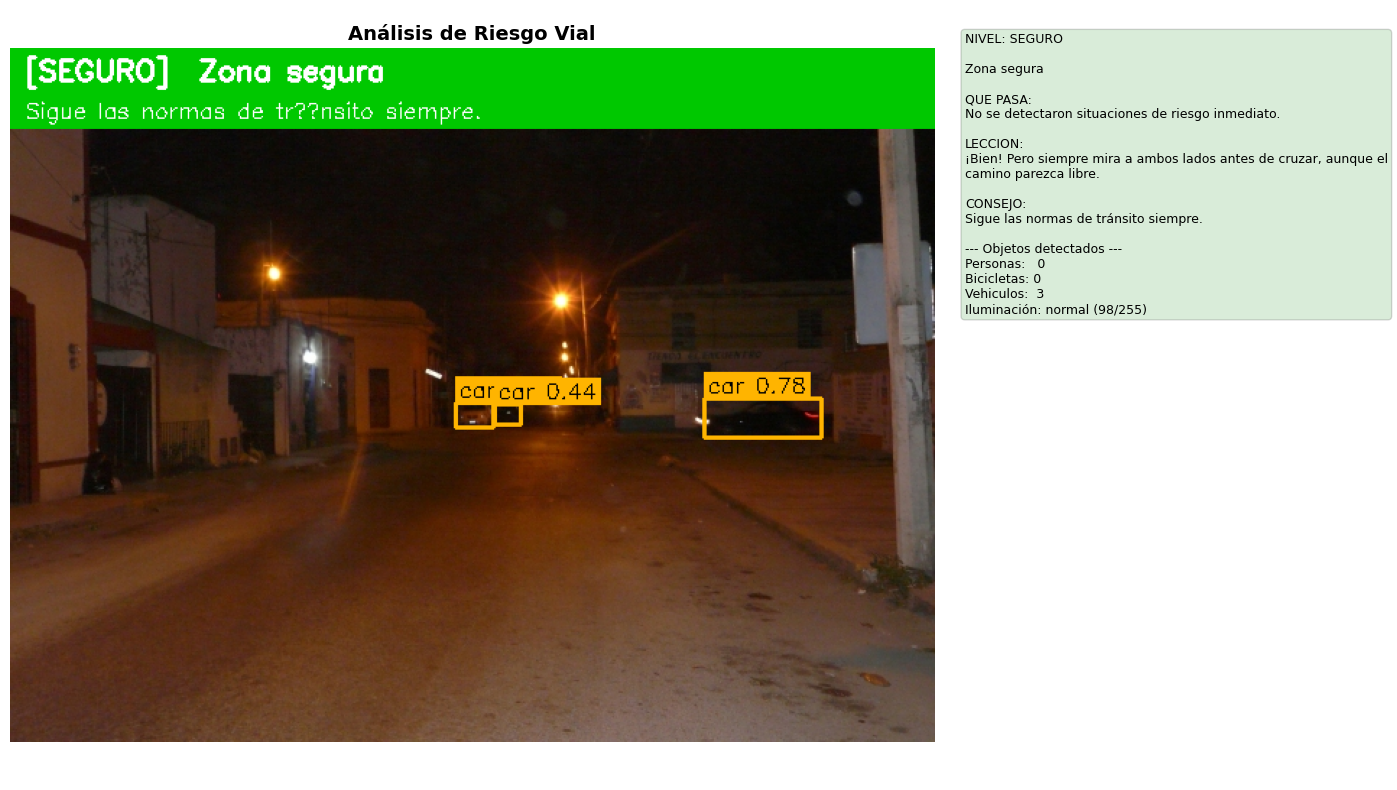

In [7]:
dets1, risk1 = run_pipeline("calle1.jpg")

## Test con calle2.jpg

Imagen:       calle3oscura.jpg (1280x868)
Tiempo:       247.1 ms
Objetos:      0 detectados
Iluminación:  BAJA — tenue (brillo p75=81.0/255)
Riesgo:       [WARNING] Precaución: Zona con poca iluminación
Lección:      Evita caminar solo por callejones o zonas oscuras. Usa ropa reflectante y lleva una linterna.


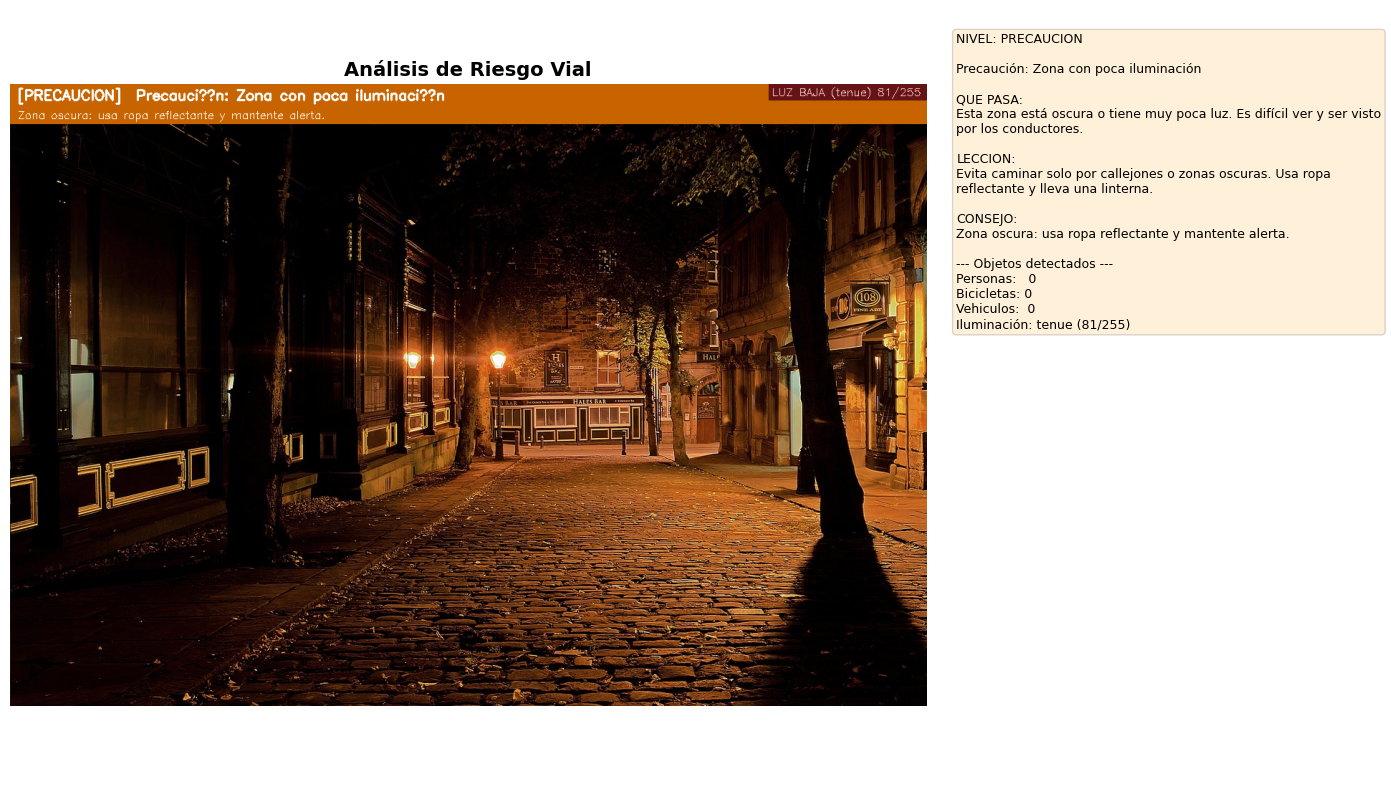

In [10]:
dets2, risk2 = run_pipeline("calle3oscura.jpg")

Test con cualquier imagen o video frame

Imagen:       calle3.png (1278x713)
Tiempo:       365.0 ms
Objetos:      6 detectados
  - person          conf=0.867  bbox=[180, 0, 331, 206]
  - motorcycle      conf=0.718  bbox=[277, 54, 403, 243]
  - car             conf=0.951  bbox=[612, 0, 1273, 698]
  - car             conf=0.533  bbox=[348, 71, 428, 137]
  - car             conf=0.550  bbox=[149, 60, 428, 162]
  - car             conf=0.356  bbox=[148, 69, 252, 161]
Iluminación:  OK — normal (brillo p75=170.0/255)
Riesgo:       [CRITICAL] ¡PELIGRO! Riesgo de atropello
Lección:      Nunca cruces entre vehículos. Usa la senda peatonal y espera que los autos se detengan completamente.


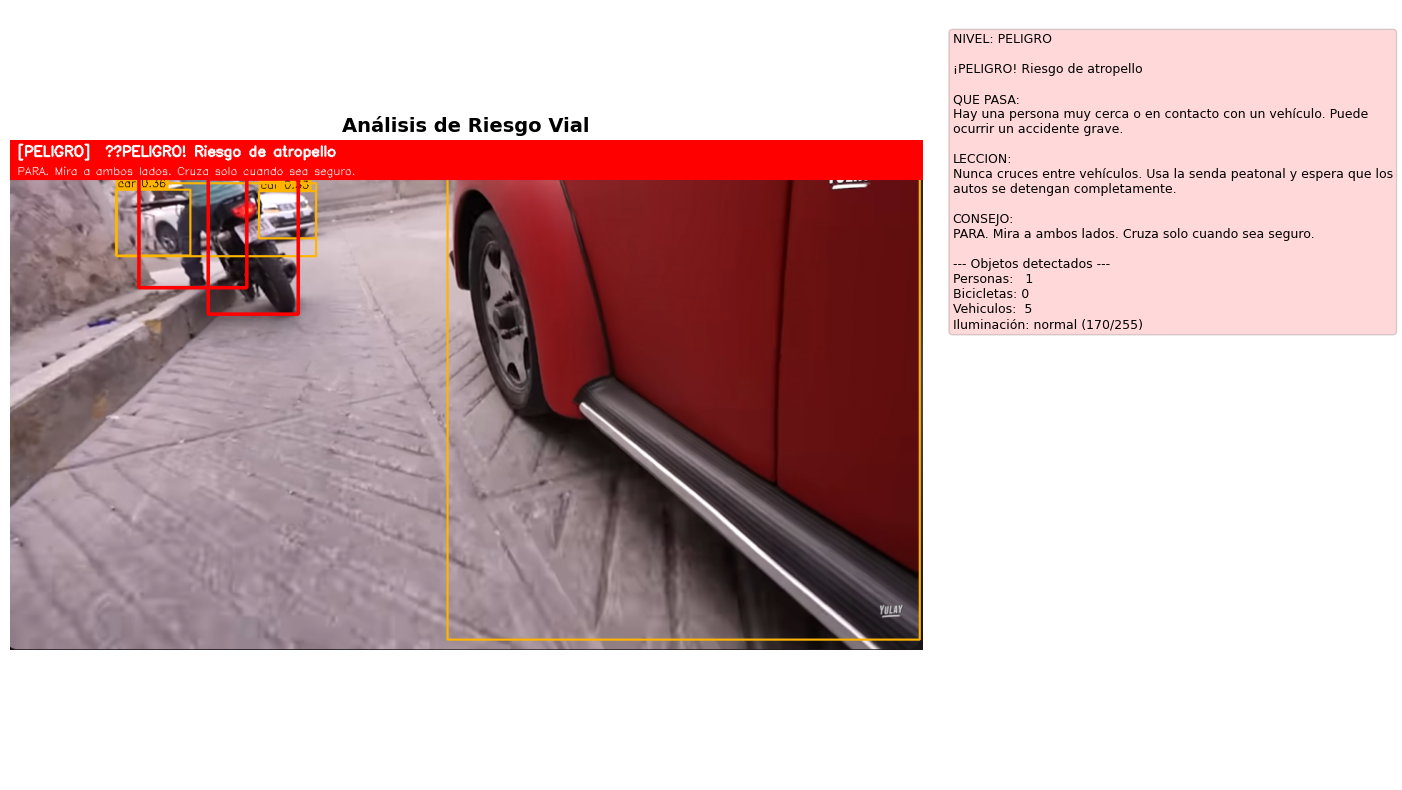

In [11]:
TEST_IMAGE = "calle3.png"   # <-- cambia esto

dets, risk = run_pipeline(TEST_IMAGE, conf_threshold=0.35)

Test con video (frame a frame)
Útil para probar con grabaciones del simulador

Procesando video: grabacion1.mp4
FPS original: 30.0
Frames totales: 184

Frames analizados: 30
CRITICAL: 0 frames
SAFE:     30 frames


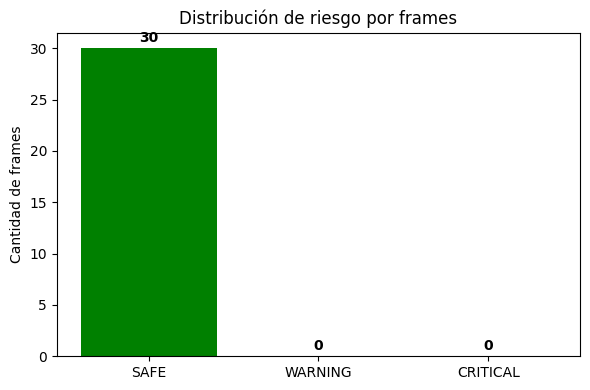

In [ ]:
VIDEO_PATH = "grabacion1.mp4"
MAX_FRAMES  = 30 
SAMPLE_RATE = 5 

if VIDEO_PATH and os.path.exists(VIDEO_PATH):
    cap = cv2.VideoCapture(VIDEO_PATH)
    frame_count = 0
    analyzed = 0
    results = []

    print(f"Procesando video: {VIDEO_PATH}")
    print(f"FPS original: {cap.get(cv2.CAP_PROP_FPS):.1f}")
    print(f"Frames totales: {int(cap.get(cv2.CAP_PROP_FRAME_COUNT))}")

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_count += 1

        if frame_count % SAMPLE_RATE != 0:
            continue

        t0 = time.time()
        dets = detector.detect(frame)
        risk = analyze_risk(dets, frame.shape)
        dt   = (time.time() - t0) * 1000

        results.append({"frame": frame_count, "risk": risk["risk_level"],
                         "scenario": risk["titulo"], "ms": round(dt,1)})
        analyzed += 1

        if MAX_FRAMES and analyzed >= MAX_FRAMES:
            break

    cap.release()

    # Resumen
    print(f"\nFrames analizados: {analyzed}")
    critical = [r for r in results if r["risk"] == "CRITICAL"]
    warnings  = [r for r in results if r["risk"] == "WARNING"]
    print(f"CRITICAL: {len(critical)} frames")
    print(f"WARNING:  {len(warnings)} frames")
    print(f"SAFE:     {analyzed - len(critical) - len(warnings)} frames")

    risk_counts = {"SAFE": 0, "WARNING": 0, "CRITICAL": 0}
    for r in results: risk_counts[r["risk"]] += 1

    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(risk_counts.keys(), risk_counts.values(),
                  color=["green", "orange", "red"])
    ax.set_title("Distribución de riesgo por frames")
    ax.set_ylabel("Cantidad de frames")
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, str(int(h)),
                ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("VIDEO_PATH no configurado o no encontrado.")
    print("Asigna VIDEO_PATH a la ruta de tu video para usar esta celda.")

## Simular escenarios peligrosos (sin imagen real)
Útil para probar la lógica del motor de riesgo con datos ficticios

In [11]:
IMAGE_W, IMAGE_H = 640, 480

# Escenario simulado 1: persona muy cerca de auto
escenario_atropello = [
    {"bbox": [200, 150, 260, 350], "class_id": 0, "class_name": "person",  "confidence": 0.91},
    {"bbox": [220, 200, 450, 400], "class_id": 2, "class_name": "car",     "confidence": 0.88},
]

# Escenario simulado 2: ciclista entre camiones
escenario_ciclista = [
    {"bbox": [300, 100, 370, 300], "class_id": 1, "class_name": "bicycle", "confidence": 0.82},
    {"bbox": [100,  50, 280, 380], "class_id": 7, "class_name": "truck",   "confidence": 0.90},
    {"bbox": [380,  80, 580, 380], "class_id": 5, "class_name": "bus",     "confidence": 0.87},
]

# Escenario simulado 3: zona segura
escenario_seguro = [
    {"bbox": [50, 200, 120, 400],  "class_id": 0, "class_name": "person",  "confidence": 0.85},
    {"bbox": [500, 180, 620, 380], "class_id": 2, "class_name": "car",     "confidence": 0.79},
]

for nombre, escenario in [
    ("Riesgo de atropello",  escenario_atropello),
    ("Ciclista entre trucks", escenario_ciclista),
    ("Zona segura",          escenario_seguro),
]:
    r = analyze_risk(escenario, (IMAGE_H, IMAGE_W))
    print(f"\n=== {nombre} ===")
    print(f"  Nivel:    [{r['risk_level']}]")
    print(f"  Titulo:   {r['titulo']}")
    print(f"  Leccion:  {r['leccion']}")
    print(f"  Consejo:  {r['consejo']}")


=== Riesgo de atropello ===
  Nivel:    [CRITICAL]
  Titulo:   ¡PELIGRO! Riesgo de atropello
  Leccion:  Nunca cruces entre vehículos. Usa la senda peatonal y espera que los autos se detengan completamente.
  Consejo:  PARA. Mira a ambos lados. Cruza solo cuando sea seguro.

=== Ciclista entre trucks ===
  Nivel:    [WARNING]
  Titulo:   Precaución: Ciclista en zona de riesgo
  Leccion:  Si andas en bicicleta, usa el carril exclusivo. Nunca pases junto a camiones o buses.
  Consejo:  Usa la ciclovía. Sé visible con colores brillantes.

=== Zona segura ===
  Nivel:    [WARNING]
  Titulo:   Peatón en la calzada
  Leccion:  La calzada es solo para vehículos. Siempre camina por la vereda.
  Consejo:  Sube a la vereda inmediatamente.


Simular zona oscura / callejón con poca luz


In [ ]:
# Test de iluminación con imágenes sintéticas (no necesita modelo ni imagen real)

print("=== Test de detección de iluminación ===")

img_oscura = np.full((480, 640, 3), 30,  dtype=np.uint8)  # callejón de noche
img_tenue  = np.full((480, 640, 3), 70,  dtype=np.uint8)  # atardecer / zona poco iluminada
img_normal = np.full((480, 640, 3), 150, dtype=np.uint8)  # día normal

for nombre, img in [("Callejón oscuro", img_oscura),
                    ("Zona tenue",      img_tenue),
                    ("Día normal",      img_normal)]:
    luz = analyze_lighting(img)
    print(f"  {nombre:20s} -> nivel={luz['nivel_luz']:6s}  brillo={luz['brightness']}/255  is_dark={luz['is_dark']}")

print()

# Escenario: callejón vacío y oscuro
r = analyze_risk([], (480, 640), image=img_oscura)
print(f"Callejón vacío oscuro  -> [{r['risk_level']}] {r['titulo']}")
print(f"  Consejo: {r['consejo']}")

# Escenario: zona tenue CON vehículo y persona (debería ser CRITICAL)
escenario_oscuro_trafico = [
    {"bbox": [50,  200, 150, 400], "class_id": 0, "class_name": "person", "confidence": 0.82},
    {"bbox": [350, 150, 600, 420], "class_id": 2, "class_name": "car",    "confidence": 0.89},
]
r2 = analyze_risk(escenario_oscuro_trafico, (480, 640), image=img_tenue)
print(f"\nCallejón tenue + auto  -> [{r2['risk_level']}] {r2['titulo']}")
print(f"  Consejo:     {r2['consejo']}")
print(f"  Iluminación: {r2['stats']['iluminacion']}")


Probar la API REST
Primero ejecuta el servidor:  `python main.py`

In [ ]:
import requests, json

API_URL = "http://localhost:8000"
TEST_IMG = "calle1.jpg"

# Health check
try:
    r = requests.get(f"{API_URL}/health", timeout=3)
    print("Health:", json.dumps(r.json(), indent=2))
except Exception as e:
    print(f"Servidor no disponible: {e}")
    print("Ejecuta primero: python main.py")

# Analyze
try:
    with open(TEST_IMG, "rb") as f:
        r = requests.post(f"{API_URL}/analyze", files={"file": f}, timeout=15)
    result = r.json()
    print(f"\nResultado /analyze para {TEST_IMG}:")
    print(f"  Nivel:    {result['risk_level']}")
    print(f"  Titulo:   {result['titulo']}")
    print(f"  Leccion:  {result['leccion']}")
    print(f"  Tiempo:   {result['inference_time_ms']} ms")
    print(f"  Stats:    {result['stats']}")
except Exception as e:
    print(f"Error en /analyze: {e}")